CNN model loaded successfully!


Saving WhatsApp Image 2026-07-25 at 1.42.38 PM.jpeg to WhatsApp Image 2026-07-25 at 1.42.38 PM (1).jpeg
Uploaded image: WhatsApp Image 2026-07-25 at 1.42.38 PM (1).jpeg


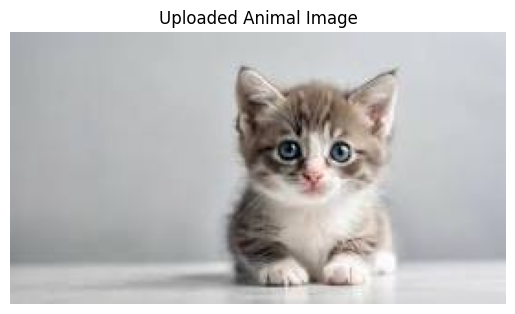

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top 3 Predictions:
1. Egyptian cat: 59.36%
2. tabby: 4.04%
3. weasel: 2.73%


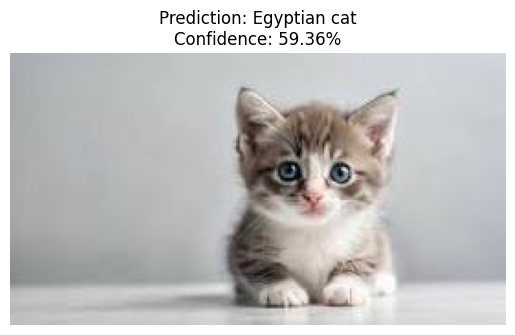

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)

from tensorflow.keras.preprocessing import image
from google.colab import files

# 1. Load pretrained CNN
model = MobileNetV2(weights="imagenet")

print("CNN model loaded successfully!")

# 2. Upload an animal image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded image:", filename)

# 3. Display original image
original_image = image.load_img(filename)

plt.imshow(original_image)
plt.title("Uploaded Animal Image")
plt.axis("off")
plt.show()

# 4. Resize image for MobileNetV2
img = image.load_img(
    filename,
    target_size=(224, 224)
)

# 5. Convert image into an array
img_array = image.img_to_array(img)

# 6. Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

# 7. Preprocess image
img_array = preprocess_input(img_array)

# 8. Make prediction
predictions = model.predict(img_array)

# 9. Decode top three predictions
results = decode_predictions(
    predictions,
    top=3
)[0]

# 10. Print predictions
print("\nTop 3 Predictions:")

for number, result in enumerate(results, start=1):

    predicted_name = result[1].replace("_", " ")
    confidence = result[2] * 100

    print(
        f"{number}. {predicted_name}: "
        f"{confidence:.2f}%"
    )

# 11. Get best prediction
best_name = results[0][1].replace("_", " ")
best_confidence = results[0][2] * 100

# 12. Display final result
plt.imshow(original_image)

plt.title(
    f"Prediction: {best_name}\n"
    f"Confidence: {best_confidence:.2f}%"
)

plt.axis("off")
plt.show()

